In [64]:
import sys
print(sys.executable)

c:\Games\Medical\venv\Scripts\python.exe


In [65]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text

DB_USER = "root"
DB_PASSWORD = "satya"
DB_HOST = "localhost"
DB_PORT = 3306
DB_NAME = "trend2action"

engine = create_engine(
    f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@"
    f"{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print("MySQL connection created successfully.")

MySQL connection created successfully.


In [66]:
with engine.connect() as connection:
    result = connection.execute(text("SELECT 1"))
    print(result.fetchone())

(1,)


In [67]:
query = """
SELECT *
FROM medical_cost_data
"""

df = pd.read_sql(query, engine)

print("Data loaded from MySQL")
print("Shape:", df.shape)

Data loaded from MySQL
Shape: (14284, 36)


In [68]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
df.head()
df.info()

Dataset Shape: (14284, 36)

Column Names:
['record_id', 'member_id', 'month', 'age', 'gender', 'bmi', 'smoking_status', 'diabetes', 'hypertension', 'heart_disease', 'asthma', 'physical_activity', 'daily_steps', 'sleep_hours', 'stress_level', 'doctor_visits', 'hospital_admissions', 'emergency_visits', 'specialist_visits', 'lab_tests', 'medication_count', 'insurance_type', 'insurance_coverage_percent', 'city_type', 'previous_year_medical_cost', 'out_of_network_rate', 'generic_rate', 'pharmacy_spend', 'average_length_of_stay_days', 'site_of_care', 'provider_type', 'provider_mix_index', 'unit_cost', 'drug_category', 'drug_cost', 'monthly_medical_cost']
<class 'pandas.DataFrame'>
RangeIndex: 14284 entries, 0 to 14283
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   record_id                    14284 non-null  str    
 1   member_id                    14284 non-null  str    
 2   month   

In [69]:
print(df.columns.tolist())
print(df["monthly_medical_cost"].describe())

['record_id', 'member_id', 'month', 'age', 'gender', 'bmi', 'smoking_status', 'diabetes', 'hypertension', 'heart_disease', 'asthma', 'physical_activity', 'daily_steps', 'sleep_hours', 'stress_level', 'doctor_visits', 'hospital_admissions', 'emergency_visits', 'specialist_visits', 'lab_tests', 'medication_count', 'insurance_type', 'insurance_coverage_percent', 'city_type', 'previous_year_medical_cost', 'out_of_network_rate', 'generic_rate', 'pharmacy_spend', 'average_length_of_stay_days', 'site_of_care', 'provider_type', 'provider_mix_index', 'unit_cost', 'drug_category', 'drug_cost', 'monthly_medical_cost']
count     14284.000000
mean      11467.703588
std       14451.539308
min         250.000000
25%        2487.355000
50%        4456.505000
75%       18223.485000
max      390000.000000
Name: monthly_medical_cost, dtype: float64


In [70]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

print("Total missing values:", df.isnull().sum().sum())

print("Duplicate rows:", df.duplicated().sum())

df[df.duplicated()].head()

df["monthly_medical_cost"].describe()

Series([], dtype: int64)
Total missing values: 0
Duplicate rows: 0


count     14284.000000
mean      11467.703588
std       14451.539308
min         250.000000
25%        2487.355000
50%        4456.505000
75%       18223.485000
max      390000.000000
Name: monthly_medical_cost, dtype: float64

Data Analysis

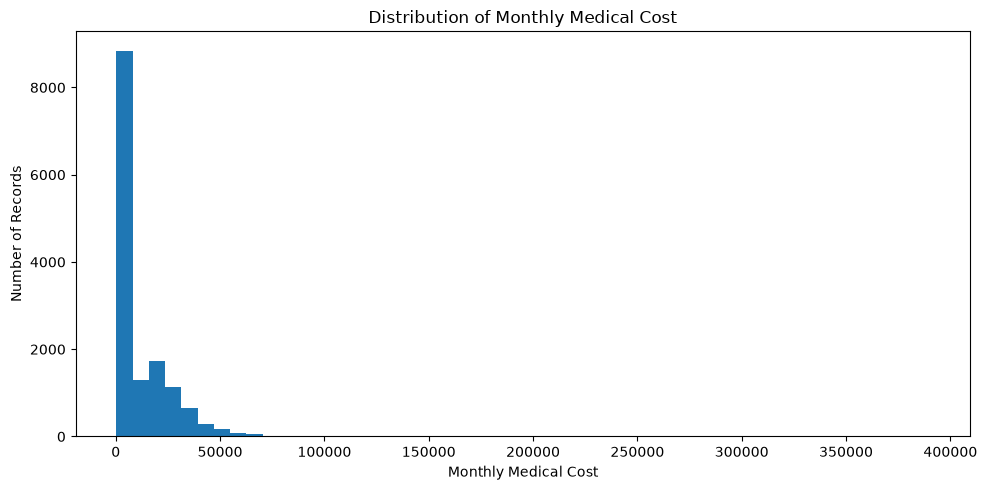

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df["monthly_medical_cost"],
    bins=50
)

plt.title("Distribution of Monthly Medical Cost")
plt.xlabel("Monthly Medical Cost")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

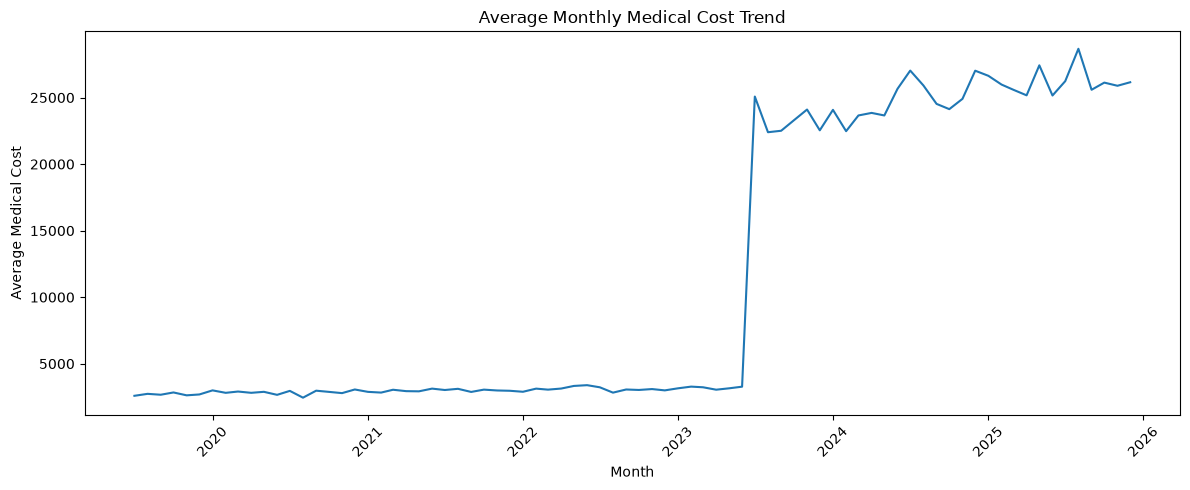

In [72]:
df["month"] = pd.to_datetime(df["month"])

monthly_cost = (
    df.groupby("month")["monthly_medical_cost"]
      .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_cost.index,
    monthly_cost.values
)

plt.title("Average Monthly Medical Cost Trend")
plt.xlabel("Month")
plt.ylabel("Average Medical Cost")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [73]:
site_cost = (
    df.groupby("site_of_care")["monthly_medical_cost"]
      .mean()
      .sort_values(ascending=False)
)

print(site_cost)

site_of_care
in patient    22045.712500
Inpatient     17963.897591
Emergency     15006.696847
Outpatient    10012.368098
Home           9578.809080
Ambulatory     8355.751007
Unknown        5653.845878
Name: monthly_medical_cost, dtype: float64


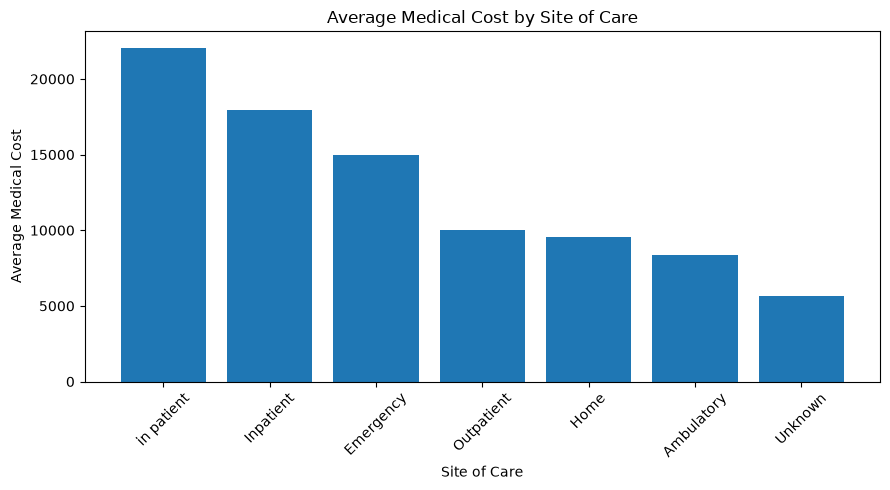

In [74]:
plt.figure(figsize=(9, 5))

plt.bar(
    site_cost.index,
    site_cost.values
)

plt.title("Average Medical Cost by Site of Care")
plt.xlabel("Site of Care")
plt.ylabel("Average Medical Cost")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

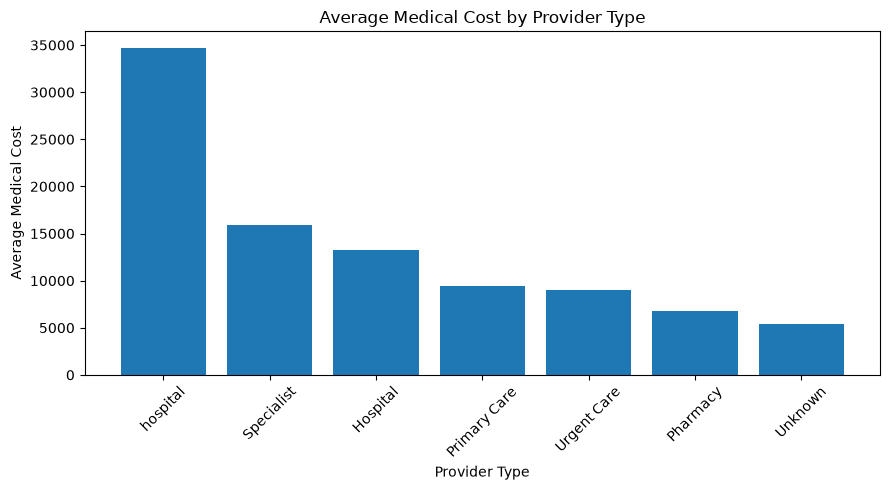

In [75]:
provider_cost = (
    df.groupby("provider_type")["monthly_medical_cost"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.bar(
    provider_cost.index,
    provider_cost.values
)

plt.title("Average Medical Cost by Provider Type")
plt.xlabel("Provider Type")
plt.ylabel("Average Medical Cost")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

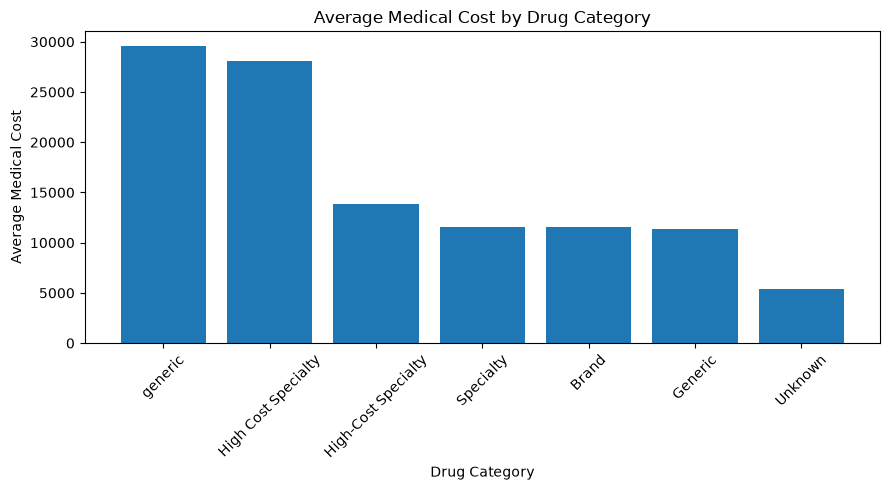

In [76]:
drug_cost_analysis = (
    df.groupby("drug_category")["monthly_medical_cost"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.bar(
    drug_cost_analysis.index,
    drug_cost_analysis.values
)

plt.title("Average Medical Cost by Drug Category")
plt.xlabel("Drug Category")
plt.ylabel("Average Medical Cost")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

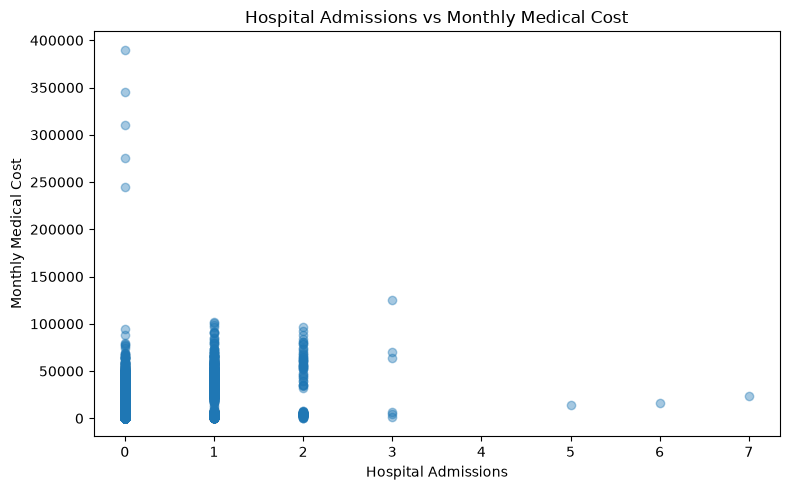

In [77]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["hospital_admissions"],
    df["monthly_medical_cost"],
    alpha=0.4
)

plt.title("Hospital Admissions vs Monthly Medical Cost")
plt.xlabel("Hospital Admissions")
plt.ylabel("Monthly Medical Cost")

plt.tight_layout()
plt.show()

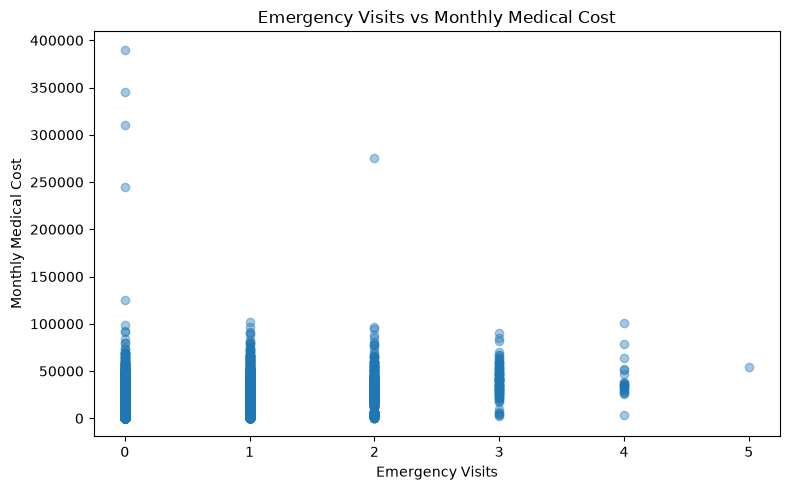

In [78]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["emergency_visits"],
    df["monthly_medical_cost"],
    alpha=0.4
)

plt.title("Emergency Visits vs Monthly Medical Cost")
plt.xlabel("Emergency Visits")
plt.ylabel("Monthly Medical Cost")

plt.tight_layout()
plt.show()

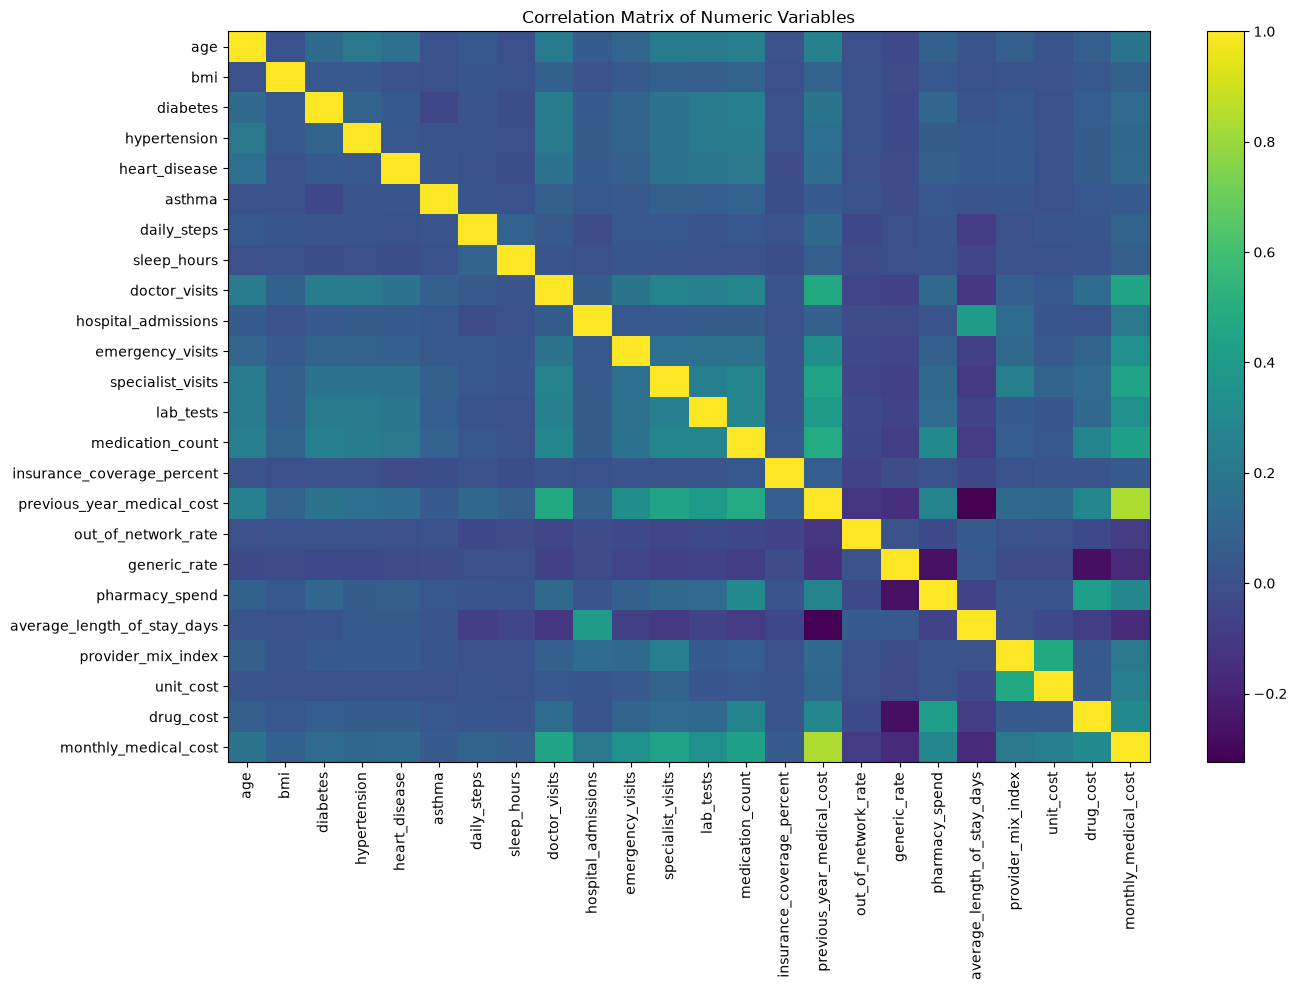

In [79]:
numeric_df = df.select_dtypes(include="number")

corr = numeric_df.corr()


plt.figure(figsize=(14, 10))

plt.imshow(corr, aspect="auto")

plt.colorbar()

plt.title("Correlation Matrix of Numeric Variables")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.tight_layout()
plt.show()

In [80]:
driver_analysis = pd.DataFrame({
    "Driver": [
        "Specialty / Drug Category",
        "Site of Care",
        "Provider Type",
        "Hospital Admissions",
        "Emergency Visits"
    ]
})

driver_analysis

,Driver
0,Specialty / Drug Category
1,Site of Care
2,Provider Type
3,Hospital Admissions
4,Emergency Visits


Machine Learning

In [81]:
category_fixes = {
    "insurance_type": {"private": "Private"},
    "site_of_care": {"in patient": "Inpatient"},
    "provider_type": {"hospital": "Hospital"},
    "drug_category": {"generic": "Generic", "High Cost Specialty": "High-Cost Specialty"},
}
for col, mapping in category_fixes.items():
    df[col] = df[col].replace(mapping)

In [82]:
cap = df["monthly_medical_cost"].quantile(0.995)
df["monthly_medical_cost"] = np.where(df["monthly_medical_cost"] > cap, cap, df["monthly_medical_cost"])

df["month"] = pd.to_datetime(df["month"])
df = df.sort_values(["member_id", "month"]).reset_index(drop=True)
df["year"] = df["month"].dt.year
df["month_num"] = df["month"].dt.month
df["quarter"] = df["month"].dt.quarter
start = df["month"].min()
df["time_index"] = (df["year"] - start.year) * 12 + (df["month_num"] - start.month)

df["prev_month_cost"] = df.groupby("member_id")["monthly_medical_cost"].shift(1)
df["cost_3m_avg"] = (df.groupby("member_id")["monthly_medical_cost"]
                        .shift(1).rolling(3, min_periods=1).mean()
                        .reset_index(level=0, drop=True))
monthly_prior = df["previous_year_medical_cost"] / 12
df["prev_month_cost"] = df["prev_month_cost"].fillna(monthly_prior)
df["cost_3m_avg"] = df["cost_3m_avg"].fillna(monthly_prior)

In [83]:
from sklearn.preprocessing import OneHotEncoder

TARGET = "monthly_medical_cost"
categorical_cols = ["gender", "smoking_status", "physical_activity", "stress_level",
                     "insurance_type", "city_type", "site_of_care", "provider_type", "drug_category"]
drop_cols = ["record_id", "member_id", "month", TARGET]
numeric_cols = [c for c in df.columns if c not in drop_cols + categorical_cols]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first")
encoded = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols), index=df.index)



In [84]:
X = pd.concat([df[numeric_cols], encoded_df], axis=1)
y = df[TARGET]

cutoff = df["time_index"].max() - 3
X_train, X_test = X[df["time_index"] < cutoff], X[df["time_index"] >= cutoff]
y_train, y_test = y[df["time_index"] < cutoff], y[df["time_index"] >= cutoff]

In [85]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

scaler = StandardScaler()
X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)

models = {
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42),
}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name}: RMSE={rmse:.2f} R2={r2:.4f}")

Random Forest: RMSE=4607.20 R2=0.8675
Gradient Boosting: RMSE=3725.79 R2=0.9133


In [86]:
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.linear_model import Ridge

estimators = [
    ("rf", RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3, random_state=42, n_jobs=-1)),
    ("gb", GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)),
]

voting = VotingRegressor(estimators=estimators, weights=[1, 3])   # GB weighted higher — it's stronger
stacking = StackingRegressor(estimators=estimators, final_estimator=Ridge(alpha=1.0), cv=5, n_jobs=-1)

for name, model in [("Voting", voting), ("Stacking", stacking)]:
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    print(name, "R2:", r2_score(y_test, preds))

Voting R2: 0.9092965609731545
Stacking R2: 0.9125112202791289


In [87]:

from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.base import clone

tscv = TimeSeriesSplit(n_splits=3)

# Tune Random Forest
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=1),
    {"n_estimators": randint(100, 250), "max_depth": randint(6, 14), "min_samples_leaf": randint(1, 8)},
    n_iter=8, cv=tscv, scoring="neg_root_mean_squared_error", n_jobs=-1, random_state=42,
)
rf_search.fit(X_train_s, y_train)
best_rf = rf_search.best_estimator_

# Tune Gradient Boosting
gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    {"n_estimators": randint(100, 300), "max_depth": randint(2, 5),
     "learning_rate": uniform(0.03, 0.12), "subsample": uniform(0.7, 0.3), "min_samples_leaf": randint(1, 10)},
    n_iter=10, cv=tscv, scoring="neg_root_mean_squared_error", n_jobs=-1, random_state=42,
)
gb_search.fit(X_train_s, y_train)
best_gb = gb_search.best_estimator_

# Stack the tuned versions
estimators = [("rf", best_rf), ("gb", best_gb)]
stack = StackingRegressor(estimators=estimators, final_estimator=Ridge(alpha=1.0), cv=3, n_jobs=2)
stack.fit(X_train_s, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('rf', ...), ('gb', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",Ridge()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",3
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",2
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[RandomForestR...ndom_state=42), GradientBoost...093960523315))]"
final_estimator_ final_estimator_: estimatorThe regressor fit on the output of `estimators_` and responsible forfinal predictions.,Ridge,Ridge()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,67
named_estimators_ named_estimators_: :class:`~sklearn.utils.Bunch`Attribute to access any fitted sub-estimators by name.,Bunch,{'rf': Random...93960523315))}


In [88]:
importances = best_rf.feature_importances_   # or best_gb.feature_importances_
fi = pd.DataFrame({"feature": X.columns, "importance": importances}).sort_values("importance", ascending=False)
print(fi.head(10))

                        feature  importance
15   previous_year_medical_cost    0.810039
19  average_length_of_stay_days    0.067830
21                    unit_cost    0.026220
26                   time_index    0.025492
11            specialist_visits    0.011042
22                    drug_cost    0.009151
18               pharmacy_spend    0.007527
20           provider_mix_index    0.007099
8                 doctor_visits    0.005977
10             emergency_visits    0.005472


In [89]:
def predict_cost(raw_records: dict) -> float:
    df_new = pd.DataFrame([raw_records])
    encoded = encoder.transform(df_new[categorical_cols])
    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))
    X_new = pd.concat([df_new[numeric_cols], encoded_df], axis=1).reindex(columns=X.columns, fill_value=0)
    return stack.predict(scaler.transform(X_new))[0]

In [90]:
import joblib

# Save just the model
joblib.dump(stack, "medical_cost_model.joblib")

# Better: save a full deployment bundle (model + scaler + encoder + column info)
# so you can reload and predict on new raw data without re-fitting anything
deployment_bundle = {
    "model": stack,                          # the trained Stacking (RF+GB) model
    "model_name": "Stacking (RF + GB)",
    "scaler": scaler,                        # StandardScaler used on training data
    "encoder": encoder,                      # OneHotEncoder for categorical columns
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "feature_names": X.columns.tolist(),
    "metrics": {"RMSE": 3633.23, "MAE": 2799.25, "MAPE": 12.45, "R2": 0.9251},
}

joblib.dump(deployment_bundle, "medical_cost_deployment_bundle.joblib")
print("Model saved successfully!")

Model saved successfully!
